## Setup

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="nPTqdalfzbFBBOXqJ6HF")
project = rf.workspace("jordans-workspace-dvglf").project("asl-letters-9nztm-edj1r")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ASL-Letters-1 in yolov11:: 100%|██████████| 4433/4433 [00:00<00:00, 8618.80it/s]


In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data="/content/ASL-Letters-1/data.yaml" epochs=10 imgsz=640 plots=True

[Errno 2] No such file or directory: '{HOME}'
/content
New https://pypi.org/project/ultralytics/8.4.40 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/ASL-Letters-1/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes

In [ ]:
!ls {HOME}/runs/detect/train/

ls: cannot access '{HOME}/runs/detect/train/': No such file or directory


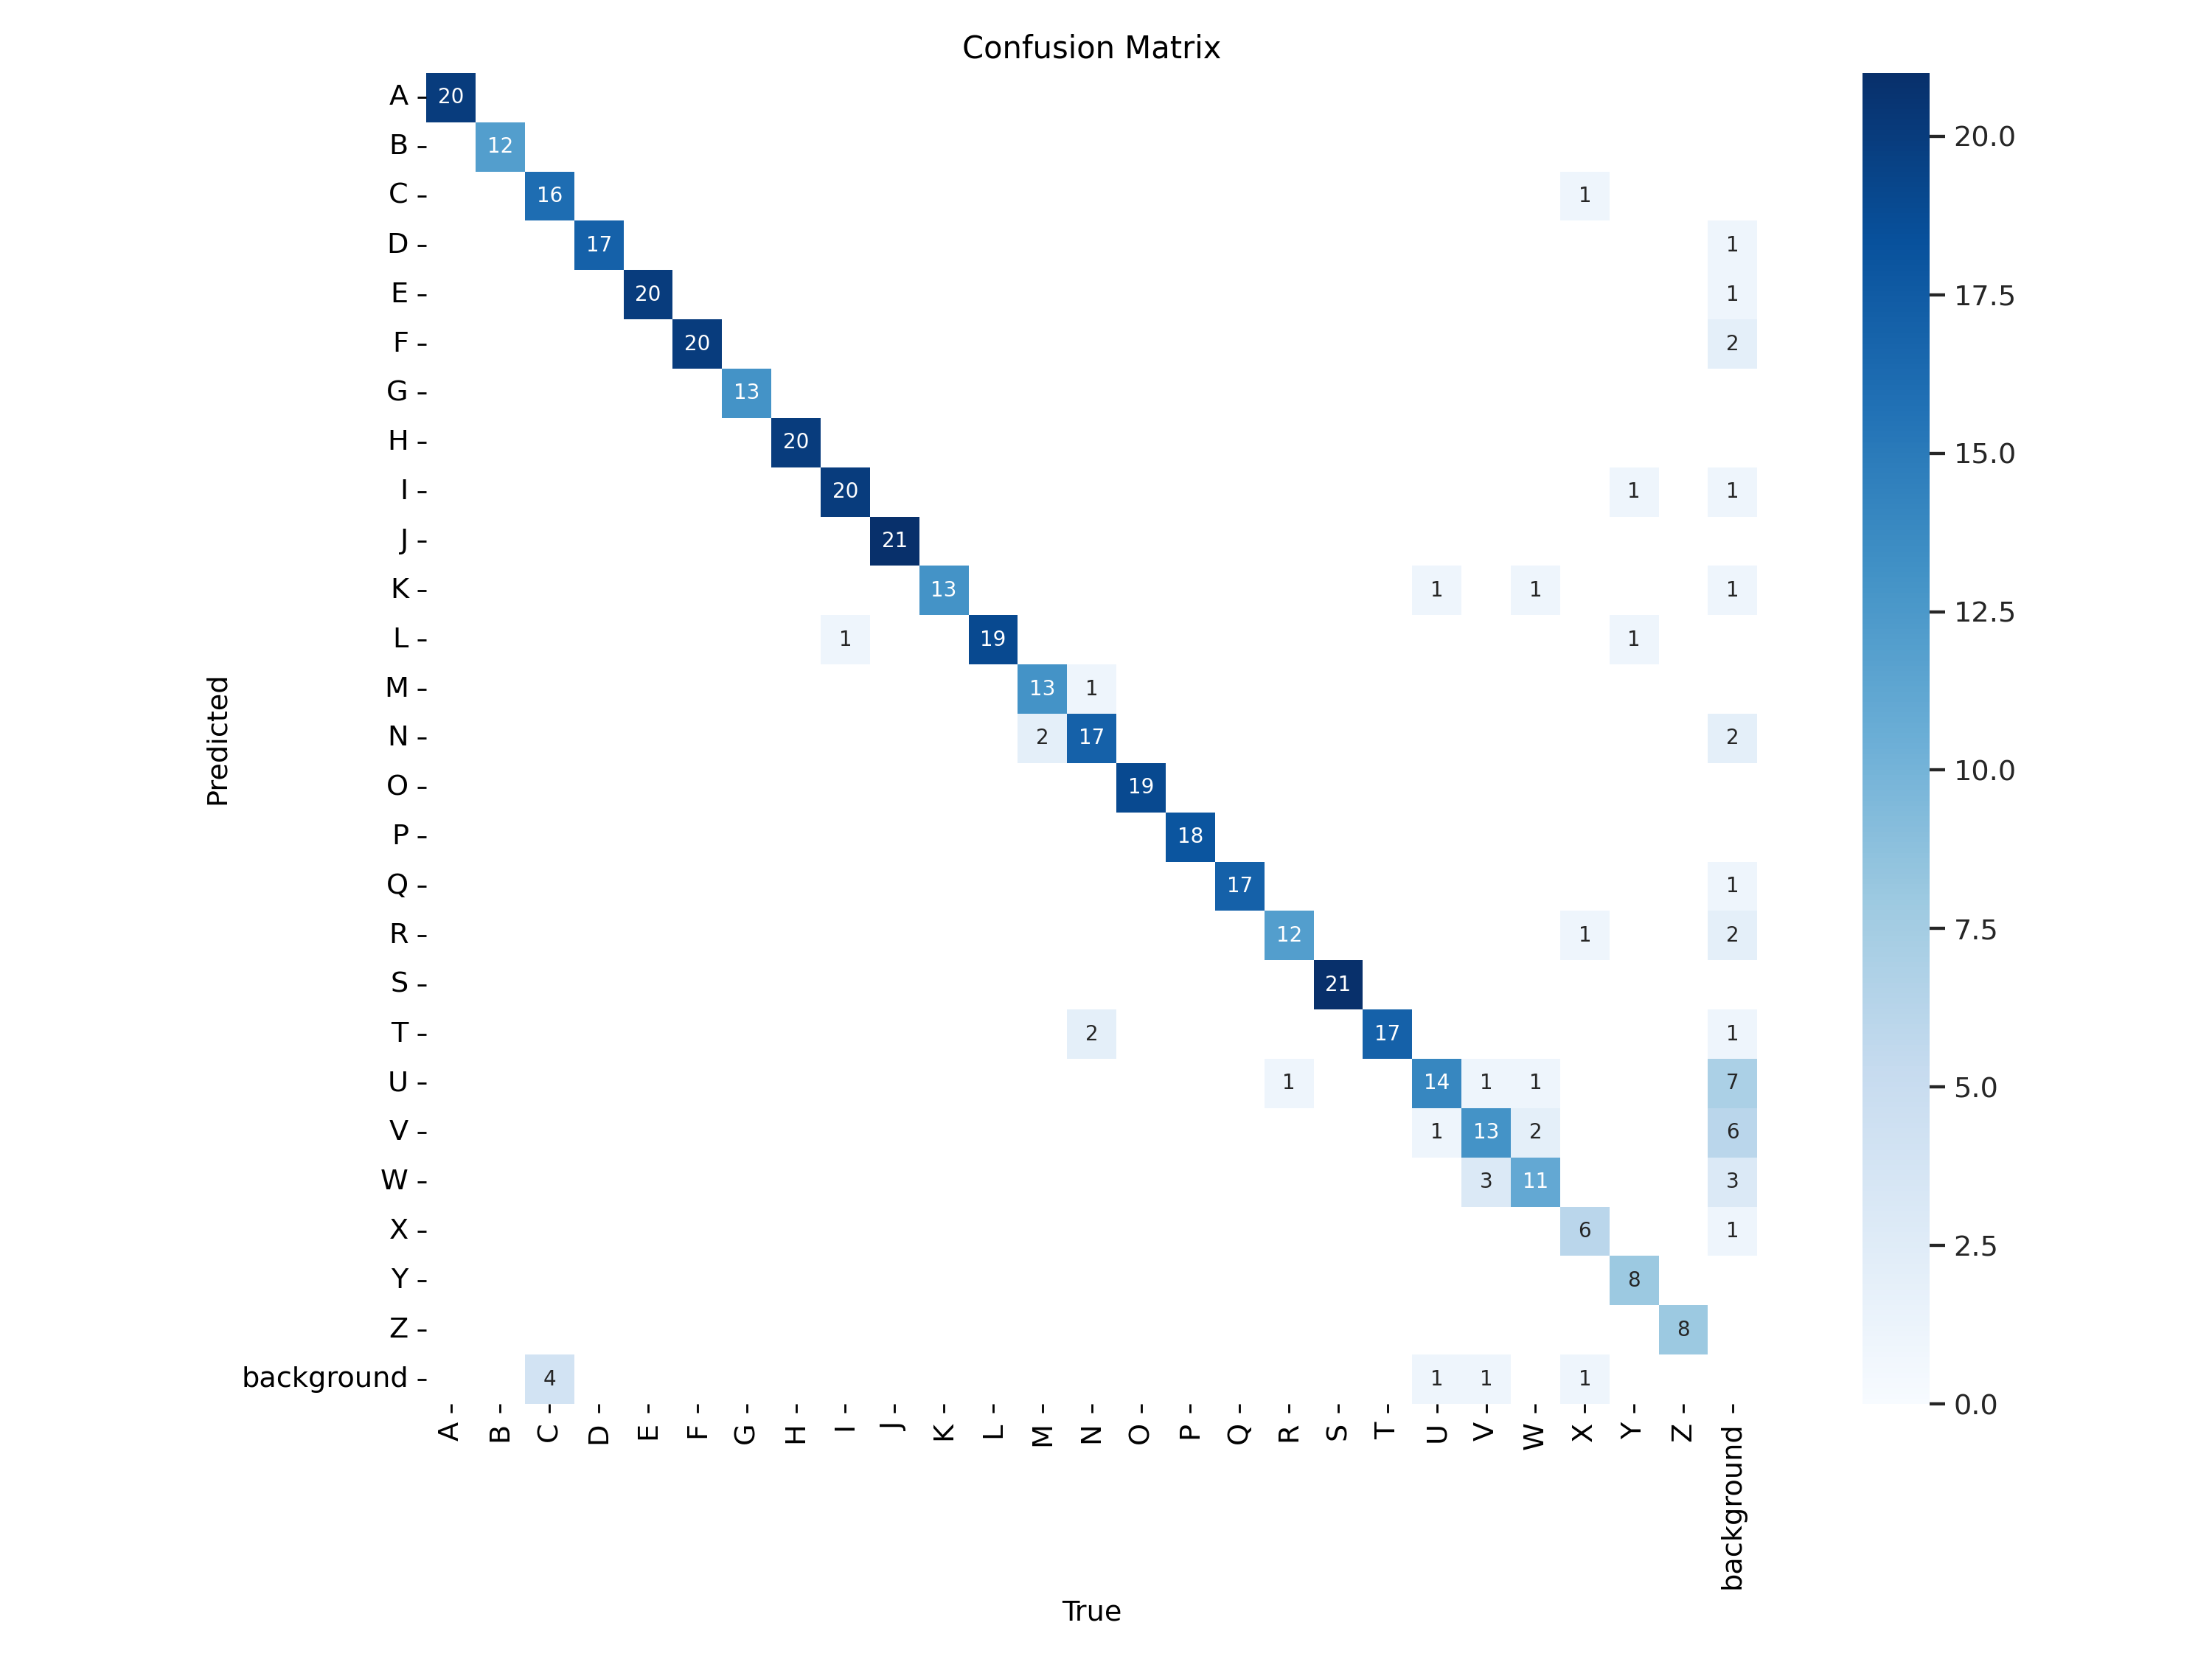

In [ ]:
import os
HOME = os.getcwd()
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train2/confusion_matrix.png', width=600)

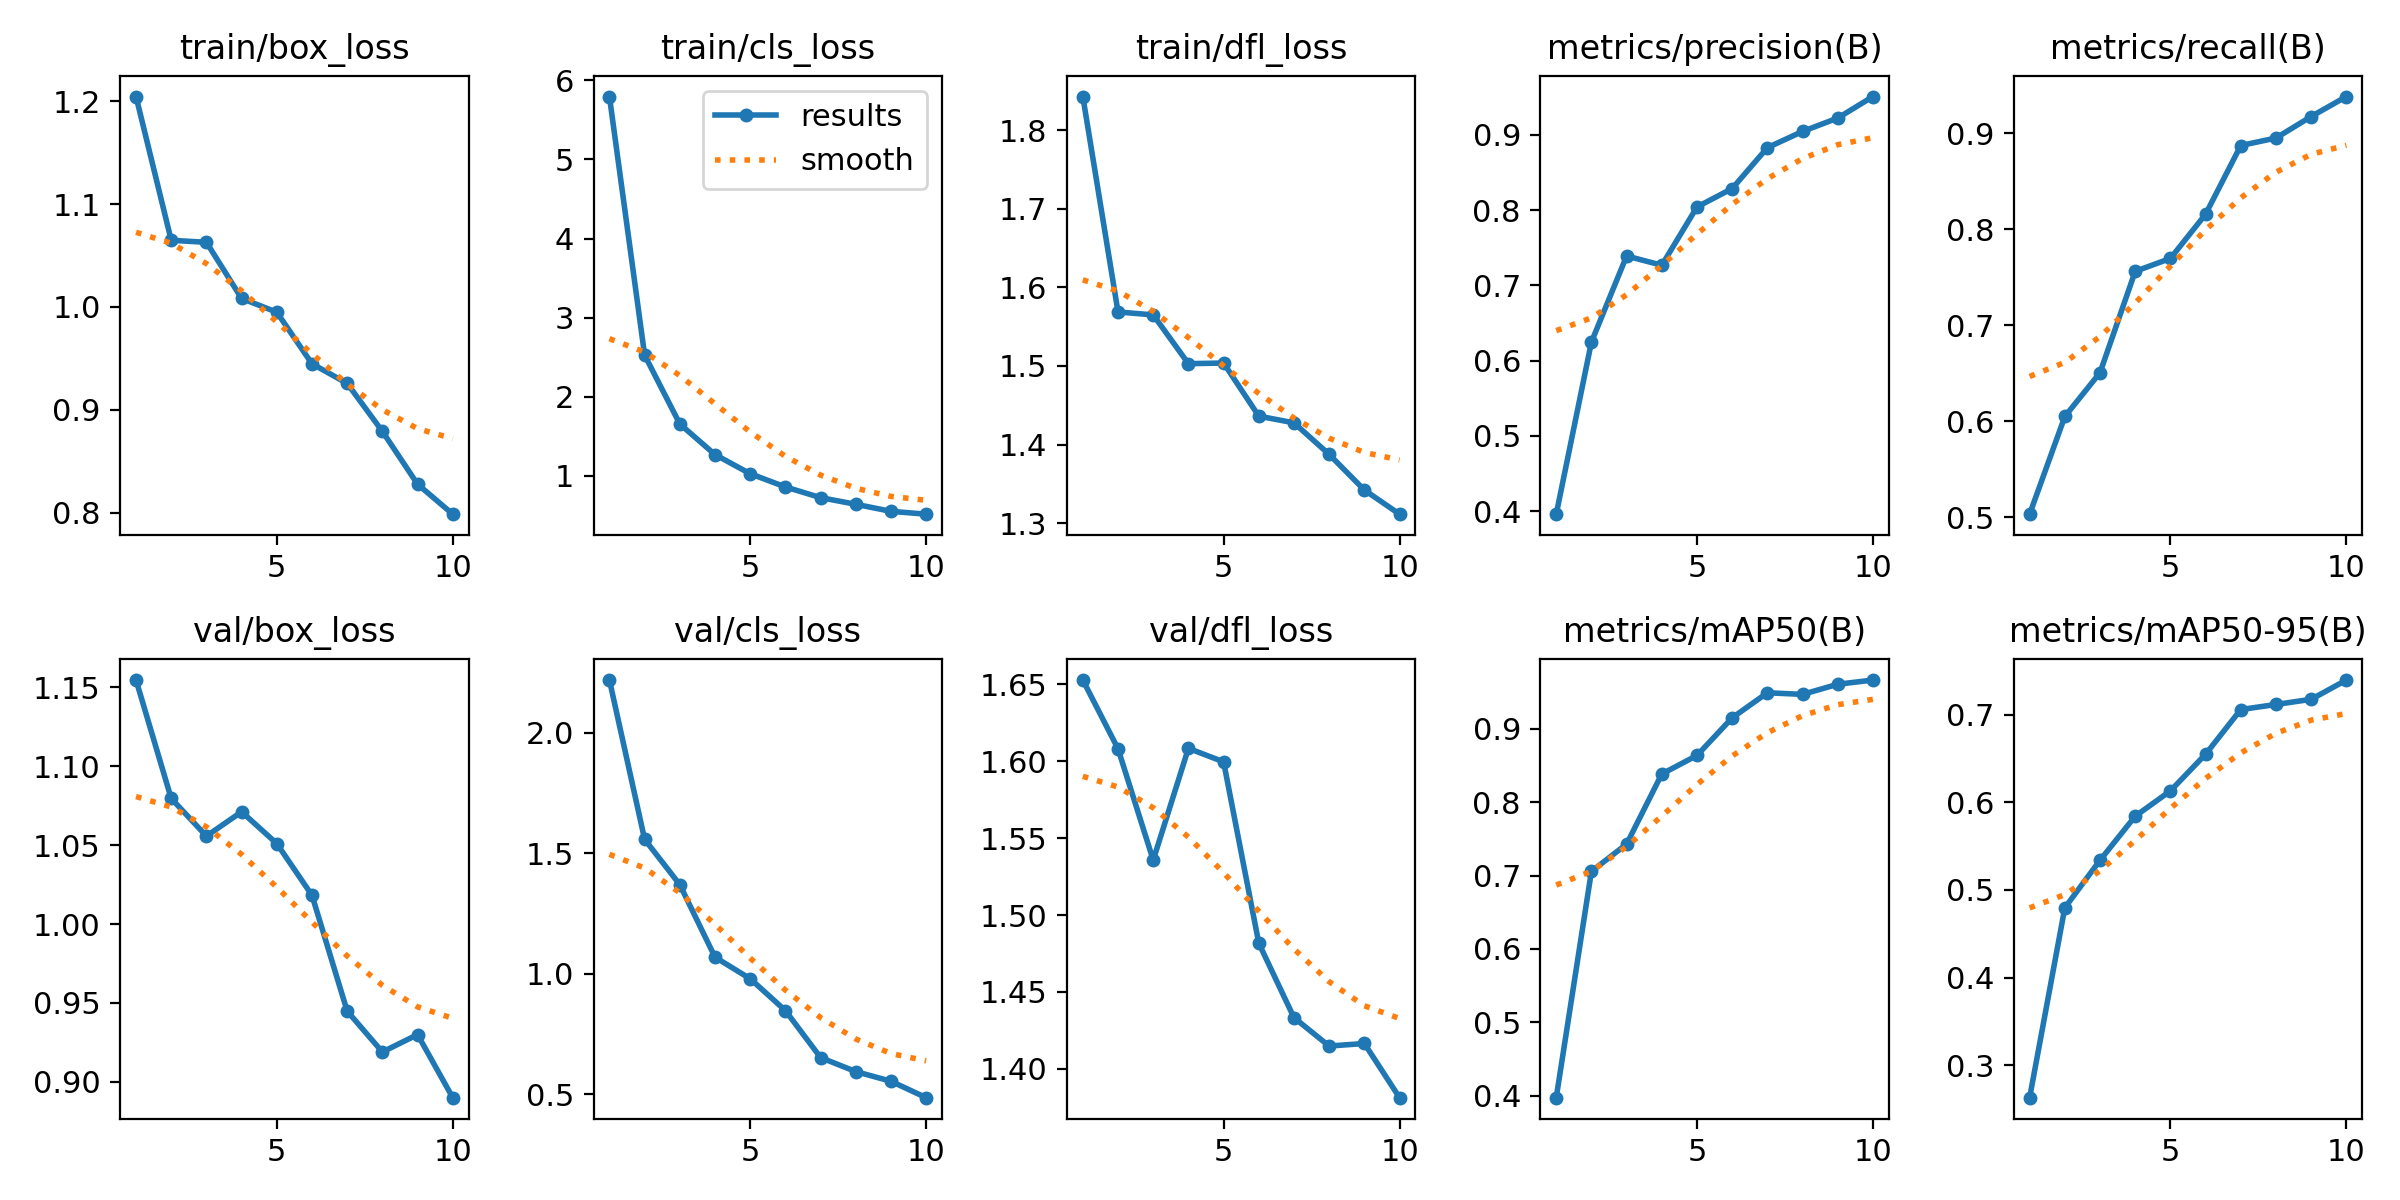

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train2/results.png', width=600)

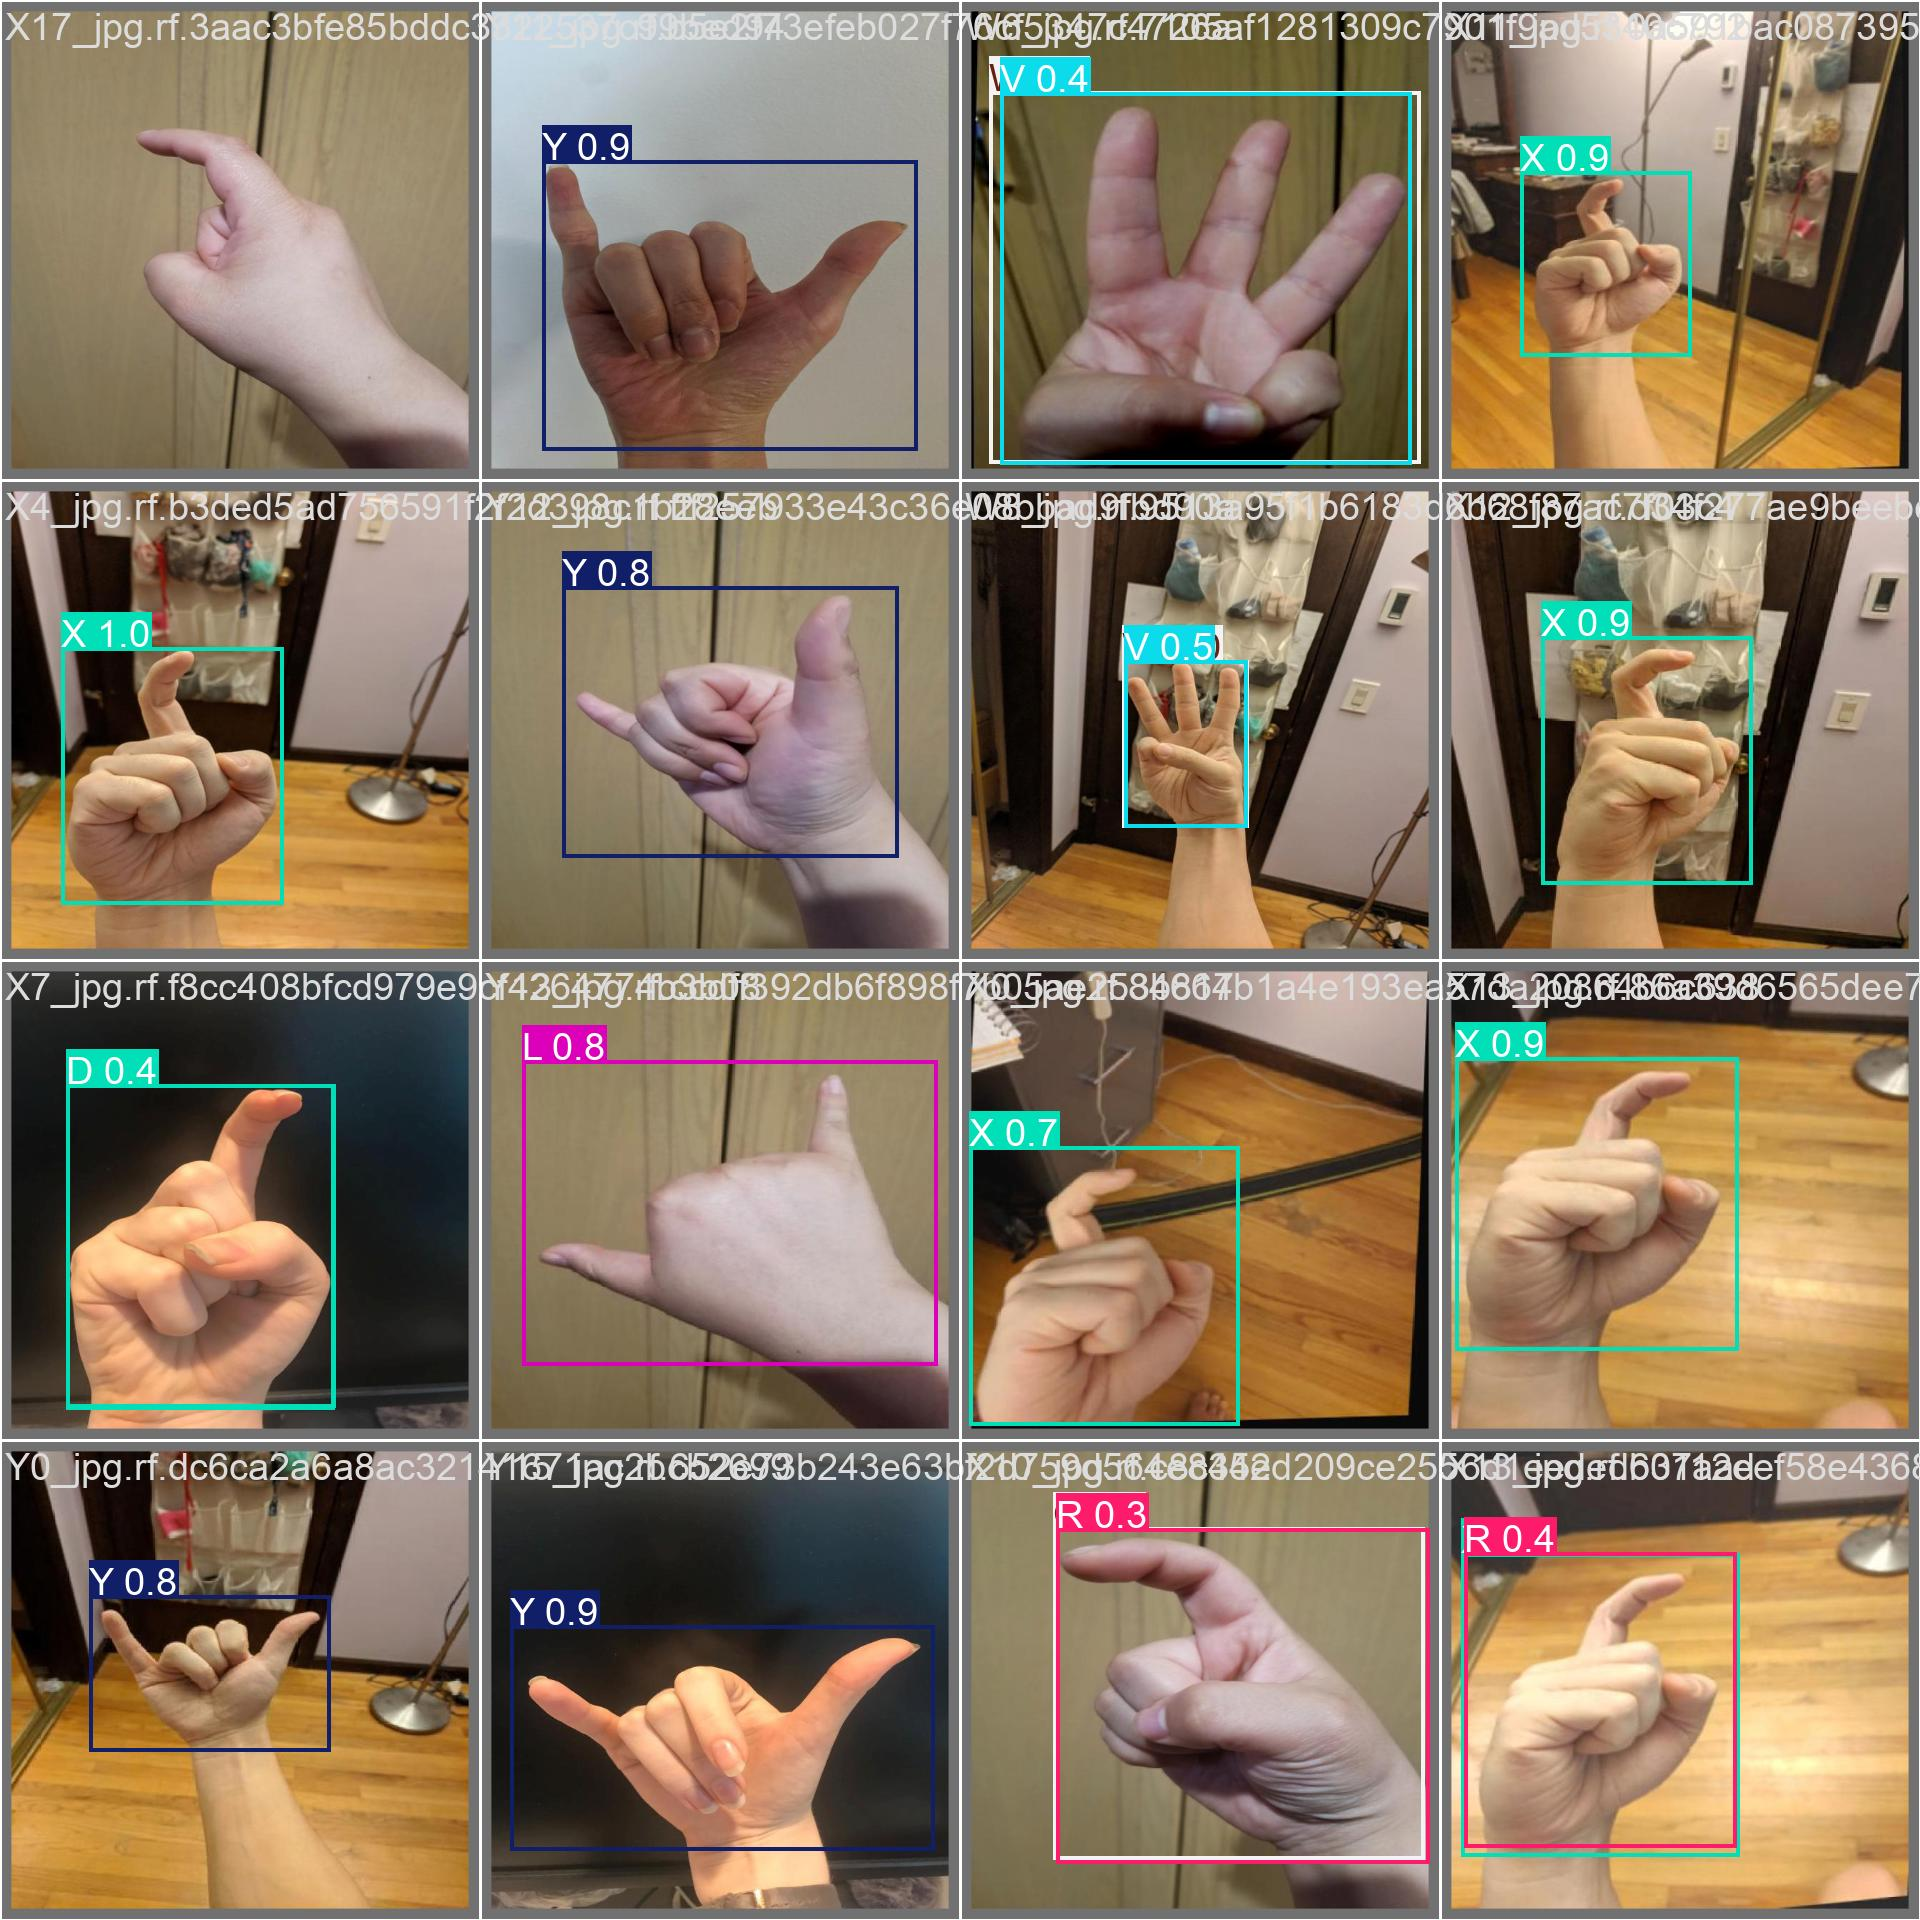

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train2/val_batch0_pred.jpg', width=600)

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train2/weights/best.pt data="{dataset.location}/data.yaml"

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,422,862 parameters, 0 gradients, 21.4 GFLOPs
val: Scanning /content/ASL-Letters-1/valid/labels.cache... 429 images, 0 backgrounds, 0 corrupt: 100% 429/429 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 8, len(boxes) = 433. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 27/27 [00:06<00:00,  4.14it/s]
                   all        429        433      0.951      0.939      0.966       0.74
                     A         20         20      0.983          1      0.995      0.816
                     B         12         12      0.961          1      0.995        0.9
                     C         16         2

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train2/weights/best.pt conf=0.25 source="{dataset.location}/test/images" save=True

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,422,862 parameters, 0 gradients, 21.4 GFLOPs

image 1/582 /content/ASL-Letters-1/test/images/A0_jpg.rf.26e8926637f962d3fbf47a7aeaf69db4.jpg: 640x640 1 A, 12.0ms
image 2/582 /content/ASL-Letters-1/test/images/A15_jpg.rf.6fb5634bab4368540ada49fbec101dc5.jpg: 640x640 1 A, 15.6ms
image 3/582 /content/ASL-Letters-1/test/images/A15_jpg.rf.efc43114490c8c7e050ec540c0b911cf.jpg: 640x640 1 A, 15.6ms
image 4/582 /content/ASL-Letters-1/test/images/A18_jpg.rf.230e2ecb8dd11b97bace30c6015caff0.jpg: 640x640 1 A, 15.5ms
image 5/582 /content/ASL-Letters-1/test/images/A22_jpg.rf.649062014db2a449c9702b02db5463bb.jpg: 640x640 1 A, 1 T, 15.5ms
image 6/582 /content/ASL-Letters-1/test/images/A24_jpg.rf.6cd598dab7dde715806bd39f0115e2b4.jpg: 640x640 1 A, 15.5ms
image 7/582 /content/ASL-Letters-1/test/images/A25_jpg.rf.e64b5191123b1222f5fa7259b44ca611.jpg: 640x640 1 A, 15.6ms
image 8/582 /con

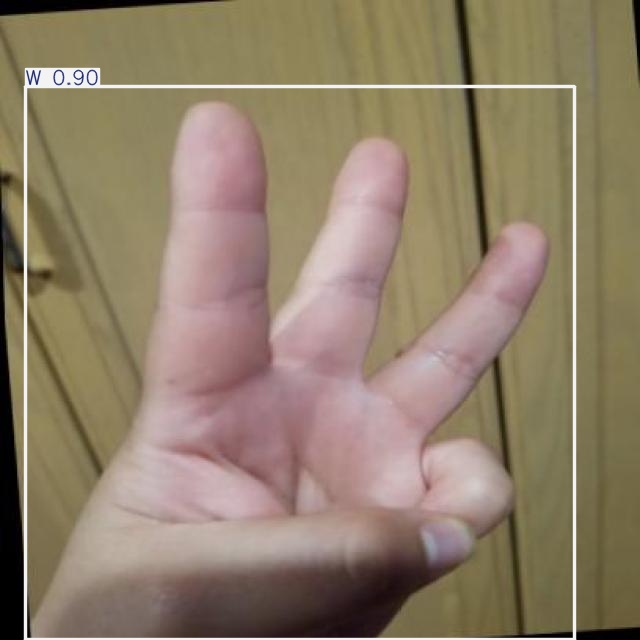

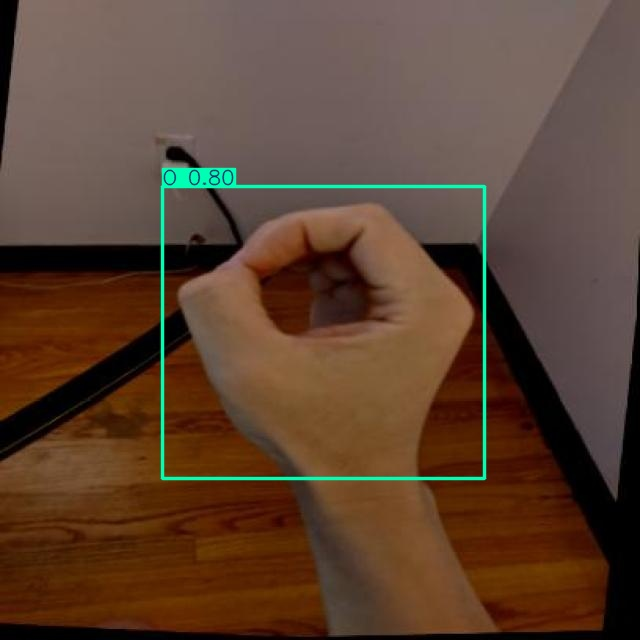

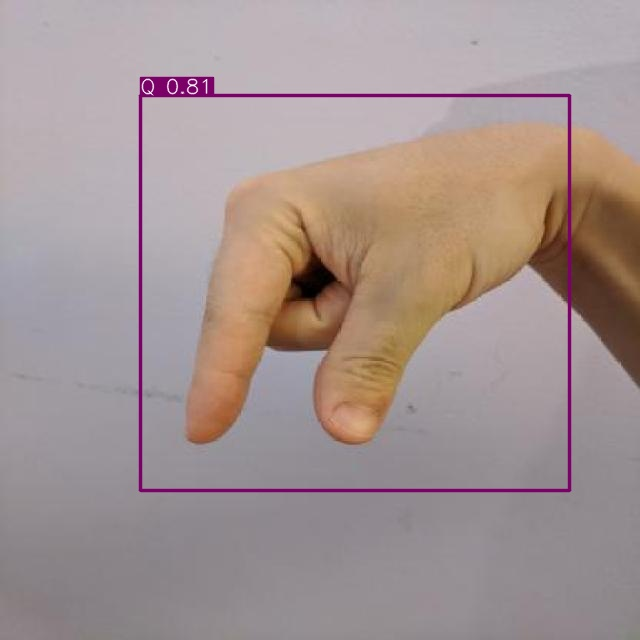

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")